In [25]:
#Autres modules importants à utiliser
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from typing import Dict, List, Optional, Tuple
import os
import sys
import pickle
import time
from skimage.restoration import denoise_tv_chambolle
from matplotlib.ticker import LogLocator
import argparse
from scipy.ndimage import zoom

## Before to use SGWB

In [26]:
#To use  GWB de Xu
!git clone https://github.com/HongtengXu/SGWB-Graphon.git
sys.path.append('./SGWB-Graphon')   # En local

print(os.listdir('SGWB-Graphon'))

from methods import learner, simulator

fatal: le chemin de destination 'SGWB-Graphon' existe déjà et n'est pas un répertoire vide.
['.git', 'README.md', 'results', 'visualize_syn_graphons.py', 'LICENSE', 'methods', '.gitignore', '.idea', 'run_comparison_synthetic.py']


## Before to use SIGL

In [27]:
# Pour utiliser SIGL
!git clone https://github.com/aliaaz99/SIGL.git
sys.path.append('./SIGL')
# Maintenant importer normalement
from tools import *

fatal: le chemin de destination 'SIGL' existe déjà et n'est pas un répertoire vide.


### JGS

In [28]:
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from jgs_utils import *
from jgs_estimator import *

In [29]:
print(dir())

['Data', 'Dict', 'F', 'GCN', 'GCNConv', 'In', 'List', 'LogLocator', 'M', 'Optional', 'Out', 'SIGL', 'Sine', 'Siren', 'SirenNet', 'Tuple', 'W_est', '_', '_24', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__session__', '__spec__', '_dh', '_exit_code', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'argparse', 'args', 'cast_tuple', 'compare_methods', 'coords_prediction', 'denoise_tv_chambolle', 'device', 'est', 'estimate_latent_positions_from_all_graphs', 'exists', 'exit', 'generate_graphs_from_graphon', 'generate_true_graphon_matrix', 'get_graphon', 'get_ipython', 'graph2XY', 'graphon_L2_norm', 'graphon_functions', 'graphon_size', 'graphs', 'graphs_data', 'gw_distance', 'interpolate_graphon', 'joint_graph_sorting_estimate', 'lea

### Initial parameters for SGWB

In [30]:
parser = argparse.ArgumentParser(description='Comparison for various methods on synthetic data')

parser.add_argument('--f-result', type=str, default='results',
                    help='the root path saving learning results')
parser.add_argument('--r', type=int, default=1000,
                    help='the resolution of graphon')
parser.add_argument('--num-graphs', type=int, default=10,
                    help='the number of synthetic graphs')
parser.add_argument('--num-nodes', type=int, default=200,
                    help='the number of nodes per graph')
parser.add_argument('--graph-size', type=str, default='random',
                    help='the size of each graph, random or fixed')
parser.add_argument('--threshold-sba', type=float, default=0.1,
                    help='the threshold of sba method')
parser.add_argument('--threshold-usvt', type=float, default=0.1,
                    help='the threshold of usvt method')
parser.add_argument('--alpha', type=float, default=0.0003,
                    help='the weight of smoothness regularizer')
parser.add_argument('--beta', type=float, default=5e-3,
                    help='the weight of proximal term')
parser.add_argument('--gamma', type=float, default=0.1,
                    help='the weight of gw term')
parser.add_argument('--inner-iters', type=int, default=50,
                    help='the number of inner iterations')
parser.add_argument('--outer-iters', type=int, default=20,
                    help='the number of outer iterations')
parser.add_argument('--n-trials', type=int, default=1,
                    help='the number of trials')

# Correction pour éviter l'erreur dans un script sans arguments
args = parser.parse_args(args=[])

# Vérification
print(args)

Namespace(f_result='results', r=1000, num_graphs=10, num_nodes=200, graph_size='random', threshold_sba=0.1, threshold_usvt=0.1, alpha=0.0003, beta=0.005, gamma=0.1, inner_iters=50, outer_iters=20, n_trials=1)


In [31]:
### Functions for comparisons of methods

In [32]:
def compare_methods(vec_n, graphon_id, REP, args, graphon_size=1000):
    """
    Compare different graphon estimation methods and measure their errors.

    Parameters:
        vec_n (list): List of generated graph sizes
        graphon_id (int): ID of the graphon used for generation
        REP (int): Number of repetitions
        args: Configuration arguments
        graphon_size (int, optional): Size of the graphon matrix (default: 1000)

    Returns:
        pd.DataFrame: DataFrame containing errors and execution times
    """

    # Configuration parameters
    inr_dim_hidden = [20, 20]
    gnn_dim_hidden = [8, 8, 8]
    n_epochs, epoch_show, w0, lr, batch_size, Res = 100, 20, 10, 0.01, 1024, 1000

    # Methods to compare
    baseline_methods = ['SBA', 'SAS', 'LG', 'MC', 'USVT', 'SGWB']
    all_methods = baseline_methods + ['SIGL', 'JGS', 'JGS_smooth']
    
    # Initialize DataFrame
    column_names = all_methods + [f"{method}_Time" for method in all_methods]
    errors_df = pd.DataFrame(columns=column_names)

    # Generate reference graphon
    true_graphon = generate_true_graphon_matrix(graphon_size, graphon_id)
    np.fill_diagonal(true_graphon, 0.0)

    for repetition in range(REP):
        print(f"Repetition: {repetition+1}/{REP}")
        row_data = {}

        # Generate graphs
        graph_data = generate_graphs_from_graphon(vec_n, graphon_id)
        graphs_inr = graph_data["graphs"]

        # Evaluate baseline methods
        for method in baseline_methods:
            start_time = time.time()
            _, estimation = learner.estimate_graphon(graphs_inr, method=method, args=args)
            elapsed_time = time.time() - start_time

            row_data[f"{method}_Time"] = elapsed_time
            np.fill_diagonal(estimation, 0.0)
            #row_data[method] = gw_distance(true_graphon, estimation)
            row_data[method] = graphon_L2_norm(true_graphon, estimation)

        # SIGL method
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Device: {device}")

        start_time = time.time()
        print("Step 1: Learning latent variables")
        model_SIGL, _ = coords_prediction(inr_dim_hidden, gnn_dim_hidden, n_epochs, 
                                        epoch_show, w0, graphs_inr, lr)

        print("Step 2: Sorting graphs and computing histogram weights")
        X_all, y_all, w_all = graph2XY(graphs_inr, model_SIGL)

        print("Step 3: Training INR to estimate graphon")
        trained_inr = train_graphon(inr_dim_hidden, w0, X_all, y_all, w_all, 
                                  n_epochs, epoch_show, lr, batch_size)

        print("Step 4: Sampling estimated graphon")
        estimated_graphon = get_graphon(Res, trained_inr)
        row_data["SIGL_Time"] = time.time() - start_time
        #row_data["SIGL"] = gw_distance(true_graphon, estimated_graphon)
        row_data["SIGL"] = graphon_L2_norm(true_graphon, estimated_graphon) 

        # JGS method (Joint Graph Sorting)
        start_time = time.time()
        estim = joint_graph_sorting_estimate(graphs_inr)
        row_data["JGS_Time"] = time.time() - start_time

       
        estim_graphon_resized = interpolate_graphon(estim["edge_frequencies"], graphon_size)
        np.fill_diagonal(estim_graphon_resized, 0.0)
        row_data["JGS"] = graphon_L2_norm(estim_graphon_resized, true_graphon)
        #row_data["JGS"] = gw_distance(estim_graphon_resized, true_graphon)

        # JGS method with smoothing
        h = int(graphon_size / estim["edge_frequencies"].shape[0]) 
        smooth_graphon = denoise_tv_chambolle(estim_graphon_resized, weight=h)
        #row_data["JGS_smooth"] = gw_distance(smooth_graphon, true_graphon)
        row_data["JGS_smooth"] = graphon_L2_norm(smooth_graphon, true_graphon)

        # Add results to DataFrame
        row_df = pd.DataFrame([row_data])

        row_df = row_df.dropna(axis=1, how='all')

        errors_df = pd.concat([errors_df, row_df], ignore_index=True)

    return errors_df

In [33]:
def smart_error_formatting(errors_df):
    """
    Adaptively format error statistics for each column in the DataFrame.
    """
    summary_stats = {}
    unit_info = {}
    
    for column in errors_df.columns:
        if not errors_df[column].isna().all():
            values = errors_df[column].values  # ← Convert to numpy array
            
            # Choose adaptive formatting
            max_val = np.max(np.abs(values))
            
            if max_val < 1e-4:
                # Scientific notation for very small values
                mean_val = np.mean(values)
                std_val = np.std(values)
                summary_stats[column] = f"{mean_val:.2e} ± {std_val:.2e}"
                unit_info[column] = ""
                
            elif max_val < 0.1:
                # Scaling ×1000 for small values
                mean_val = np.mean(values) * 1000
                std_val = np.std(values) * 1000
                summary_stats[column] = f"{mean_val:.4f} ± {std_val:.4f}"
                unit_info[column] = " (×10^{-3})"
                
            else:
                # Normal format
                mean_val = np.mean(values)
                std_val = np.std(values)
                summary_stats[column] = f"{mean_val:.4f} ± {std_val:.4f}"
                unit_info[column] = ""
    
    return summary_stats, unit_info


In [34]:
def simulate_full_with_baselines(graphon_id=1, M=10, REP=10,vec_n=np.random.randint(10, 50, size=5),args=None, graphon_size=1000):
    """
    Run a complete simulation: generate graphs from a given graphon,
    compare errors of baseline methods + JGS.
    """
    
    if args is None:
        args = default_args

    # Generate graph sizes
    #vec_n = np.random.randint(10, 100, size=M)
    # Generate graphs
    graphs_data = generate_graphs_from_graphon(vec_n, graphon_id)
    graphs = graphs_data["graphs"]

    # Compare all methods
    errors_df = compare_methods(vec_n, graphon_id, REP=REP, args=args, graphon_size=graphon_size)

    # Use adaptive scaling
    summary_stats, unit_info = smart_error_formatting(errors_df)

    # Create summary DataFrame
    summary_df = pd.DataFrame.from_dict(summary_stats, orient="index", columns=["mean ± std"])
    summary_df.index.name = "Method"
    
    # Add unit information
    summary_df['unit'] = summary_df.index.map(unit_info)

    return {
        "errors_df": errors_df,
        "summary": summary_df
    }

In [35]:
def save_methods_boxplot(results_dict, graphon_id, output_dir="results/boxplots"):
    """
    Automatically plots and saves the methods boxplot.
    
    Parameters:
        results_dict: Dictionary containing 'errors_df'
        graphon_id: Graphon ID (0-11) for filename
        output_dir: Output directory for images
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    errors_df = results_dict['errors_df']
    
    # Prepare data for boxplot
    plot_data = []
    for method in errors_df.columns:
        if not method.endswith('_Time') and not errors_df[method].isna().all():
            for value in errors_df[method].dropna():
                plot_data.append({'Method': method, 'Error': value})
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create boxplot
    plt.figure(figsize=(12, 8))
    sns.boxplot(data=plot_df, x='Method', y='Error')
    # plt.title(f'Graphon Estimation Methods Comparison (Graphon {graphon_id})', fontsize=16, fontweight='bold')
    plt.xlabel('Estimation Methods', fontsize=12)
    plt.ylabel('Error', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # Add points for individual values
    sns.stripplot(data=plot_df, x='Method', y='Error', 
                 color='black', alpha=0.5, size=4, jitter=True)
    
    # Filename with format boxplot_mise_graphon_i
    filename = f"boxplot_mise_graphon_{graphon_id}.png"
    filepath = os.path.join(output_dir, filename)
    
    # Save in high quality
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.savefig(filepath.replace('.png', '.pdf'), bbox_inches='tight')
    
    print(f"✅ Boxplot saved: {filepath}")
    plt.close()  # Close figure to free memory

# Usage for a specific graphon

In [36]:
def save_raw_data(results_dict, graphon_id, output_dir="results/raw_data"):
    """
    Saves raw data in CSV format.
    """
    os.makedirs(output_dir, exist_ok=True)
    
    # Save errors and times
    errors_filename = f"errors_times_graphon_{graphon_id}.csv"
    results_dict['errors_df'].to_csv(os.path.join(output_dir, errors_filename))
    
    # Save summary
    summary_filename = f"summary_graphon_{graphon_id}.csv"
    results_dict['summary'].to_csv(os.path.join(output_dir, summary_filename))
    
    print(f"📊 Raw data saved for Graphon {graphon_id}")

In [13]:
#Graphon 0
M=2
results0 = simulate_full_with_baselines(graphon_id=0, M=M,vec_n=np.random.randint(10, 50, size=M), REP=1, args=args)

Repetition: 1/1
1
Device: cpu
Step 1: Learning latent variables
epoch:  1  loss:  0.48277615010738373
epoch:  20  loss:  0.29168738424777985
epoch:  40  loss:  0.25841228663921356
epoch:  60  loss:  0.2330123856663704
epoch:  80  loss:  0.2148897349834442
epoch:  100  loss:  0.21882414072752
Step 2: Sorting graphs and computing histogram weights
Step 3: Training INR to estimate graphon
Epoch: 1, Loss: 0.18745
Epoch: 20, Loss: 0.01535
Epoch: 40, Loss: 0.01257
Epoch: 60, Loss: 0.01200
Epoch: 80, Loss: 0.01174
Epoch: 100, Loss: 0.01147
Step 4: Sampling estimated graphon


/tmp/ipykernel_42651/3449889689.py:96: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  errors_df = pd.concat([errors_df, row_df], ignore_index=True)


In [14]:
save_methods_boxplot(results0, graphon_id=0)
save_raw_data(results0, graphon_id=0)

/home/rbsogan/SIGL/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/rbsogan/SIGL/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/rbsogan/SIGL/venv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


✅ Boxplot saved: results/boxplots/boxplot_mise_graphon_0.png
📊 Raw data saved for Graphon 0


### Functions for time comparison

In [37]:
def run_jgs_mise_with_timing(
    graphon_id=1,
    mode="M",           # "M", "n", or "vary_one_n"
    fixed_val=30,
    mode_list=None,
    REP_errors=10,
    graphon_size=1000,
    methods: List[str] = ["JGS", "SIGL", "SGWB"]  # SGWB added
):
    """
    Explore MISE varying with execution time tracking for multiple methods.
    
    Args:
        graphon_id: ID of the graphon to generate
        mode: "M", "n", or "vary_one_n"
        fixed_val: Fixed value for the non-varying parameter
        mode_list: List of values for the chosen mode
        REP_errors: Number of repetitions for error estimation
        graphon_size: Size for graphon resizing
        methods: List of methods to compare (including SGWB)
    
    Returns:
        DataFrame with MISE results and execution times
    """

    # SIGL configuration parameters
    inr_dim_hidden = [20, 20]
    gnn_dim_hidden = [8, 8, 8]
    n_epochs, epoch_show, w0, lr, batch_size, Res = 100, 20, 10, 0.01, 1024, 1000
    
    if mode_list is None:
        mode_list = [10, 20, 50, 100]

    # Initialize DataFrame with specified columns
    results = pd.DataFrame(columns=["val", "fixed_val", "MISE", "Time", "method"])
    
    for val in mode_list:
        # Parameter configuration according to mode
        if mode == "M":
            M, n = val, fixed_val
            vec_n = np.repeat(n, M)
            description = f"M={val}, n={fixed_val}"
        elif mode == "n":
            n, M = val, fixed_val
            vec_n = np.repeat(n, M)
            description = f"n={val}, M={fixed_val}"
        elif mode == "vary_one_n":
            n_values = [fixed_val] * fixed_val
            n_values[0] = val  # only first graph varies
            vec_n = np.array(n_values)
            M = fixed_val
            description = f"M={fixed_val}, n_first={val}, n_others={fixed_val}"
        else:
            raise ValueError("mode must be 'M', 'n' or 'vary_one_n'")

        print(f"\n▶ Simulation: {description}")
        
        # Repetitions for error estimation
        for rep in range(REP_errors):
            # Graph generation
            graphs_data = generate_graphs_from_graphon(vec_n, graphon_id)
            graphs = graphs_data["graphs"]
            true_graphon = generate_true_graphon_matrix(graphon_size, graphon_id)
            
            # Evaluation for each method
            for method in methods:
                try:
                    # Create a new row
                    new_row = {
                        "val": val,
                        "fixed_val": fixed_val,
                        "method": method,
                        "MISE": np.nan,
                        "Time": np.nan
                    }
                    
                    start_time = time.time()
                    
                    if method == "JGS":
                        start_time = time.time()
                        est = joint_graph_sorting_estimate(graphs)
                        elapsed_time = time.time() - start_time
                        W_est = interpolate_graphon(est["edge_frequencies"], graphon_size)
                        mise = graphon_L2_norm(W_est, true_graphon)
                        
                    elif method == "SIGL":
                        start_time = time.time()
                        print("Step 1: Learning latent variables")
                        model_SIGL, _ = coords_prediction(inr_dim_hidden, gnn_dim_hidden, n_epochs, 
                                        epoch_show, w0, graphs, lr)

                        print("Step 2: Sorting graphs and computing histogram weights")
                        X_all, y_all, w_all = graph2XY(graphs, model_SIGL)

                        print("Step 3: Training INR to estimate graphon")
                        trained_inr = train_graphon(inr_dim_hidden, w0, X_all, y_all, w_all, 
                                  n_epochs, epoch_show, lr, batch_size)

                        print("Step 4: Sampling estimated graphon")
                        W_est = get_graphon(graphon_size, trained_inr)
                        elapsed_time = time.time() - start_time
                        mise = graphon_L2_norm(W_est, true_graphon)
                    
                    elif method == "SGWB":
                        start_time = time.time()
                        _, W_est = learner.estimate_graphon(graphs, method=method, args=args)
                        elapsed_time = time.time() - start_time
                        mise = graphon_L2_norm(W_est, true_graphon)
                    
                    # Time calculation and result update
                    
                    
                    new_row["MISE"] = mise
                    new_row["Time"] = elapsed_time
                    
                    print(f"  {method} - Rep {rep}: MISE={mise:.6f}, Time={elapsed_time:.2f}s")
                    
                    # Add new row to DataFrame
                    results = pd.concat([results, pd.DataFrame([new_row])], ignore_index=True)
                    
                except Exception as e:
                    print(f"Error with {method} at repetition {rep}: {e}")
                    # Add row with NaN values in case of error
                    new_row["method"] = method
                    results = pd.concat([results, pd.DataFrame([new_row])], ignore_index=True)

    # Reorganize columns to match specified order
    results = results[["val", "fixed_val", "MISE", "Time", "method"]]
    
    print(f"\n✅ Simulation completed. {len(results)} rows generated.")
    print(f"Expected size: {len(mode_list) * REP_errors * len(methods)} rows")
    print(f"Actual size: {len(results)} rows")
    
    return results

In [38]:

def plot_time_pointplot(results, mode, savepath=None):
    """
    Plot only the pointplot of execution times
    with larger fonts and optional saving.
    
    Parameters
    ----------
    results : DataFrame
        Must contain ['val', 'method', 'Time'] columns
    mode : str
        Name of the varying parameter (e.g., 'n' or 'M')
    savepath : str or None
        If provided, saves the figure to this path
    """
    plt.figure(figsize=(8,6))
    
    sns.pointplot(
        data=results, x="val", y="Time", hue="method",
        errorbar="sd", dodge=True, markers="o", linestyles="-"
    )
    
    # Titles and labels with large fonts
    #plt.title("Pointplot (mean ± standard deviation)", fontsize=18)
    plt.xlabel(f"Number of graphs ({mode})", fontsize=18)
    plt.ylabel("Execution time (seconds, log scale)", fontsize=18)
    
    # Log scale on Y + fine ticks
    plt.yscale("log")
    plt.gca().yaxis.set_minor_locator(LogLocator(base=10.0, subs=range(1, 10)))
    
    # Legend with larger font
    plt.legend(title="Method", fontsize=17, title_fontsize=18)
    
    plt.tight_layout()
    
    # Save if path is provided
    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"✅ Figure saved to {savepath}")
    
    plt.show()

In [17]:
resultsM=run_jgs_mise_with_timing( graphon_id=0, mode="M", 
    fixed_val=30,
    mode_list=[10,50],
    REP_errors=1,
    graphon_size=1000)


▶ Simulation: M=10, n=30
  JGS - Rep 0: MISE=0.001045, Time=0.00s
Step 1: Learning latent variables
epoch:  1  loss:  2.065188840031624


/tmp/ipykernel_42651/1215750671.py:119: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, pd.DataFrame([new_row])], ignore_index=True)


epoch:  20  loss:  1.6834408789873123
epoch:  40  loss:  1.6692522913217545
epoch:  60  loss:  1.672546148300171
epoch:  80  loss:  1.6203656196594238
epoch:  100  loss:  1.5930933877825737
Step 2: Sorting graphs and computing histogram weights
Step 3: Training INR to estimate graphon
Epoch: 1, Loss: 0.00855
Epoch: 20, Loss: 0.00341
Epoch: 40, Loss: 0.00333
Epoch: 60, Loss: 0.00329
Epoch: 80, Loss: 0.00328
Epoch: 100, Loss: 0.00327
Step 4: Sampling estimated graphon
  SIGL - Rep 0: MISE=0.010896, Time=4.56s
  SGWB - Rep 0: MISE=0.004992, Time=0.09s

▶ Simulation: M=50, n=30
  JGS - Rep 0: MISE=0.000639, Time=0.01s
Step 1: Learning latent variables
epoch:  1  loss:  9.869179338216782
epoch:  20  loss:  6.914732068777084
epoch:  40  loss:  6.759663701057434
epoch:  60  loss:  6.751904740929604
epoch:  80  loss:  6.712756469845772
epoch:  100  loss:  6.674811445176601
Step 2: Sorting graphs and computing histogram weights
Step 3: Training INR to estimate graphon
Epoch: 1, Loss: 0.00514
Ep

In [18]:
resultsM.to_csv('resultsTimeComparisonM.csv', index=False)

✅ Figure saved to pointplot_timesM.png


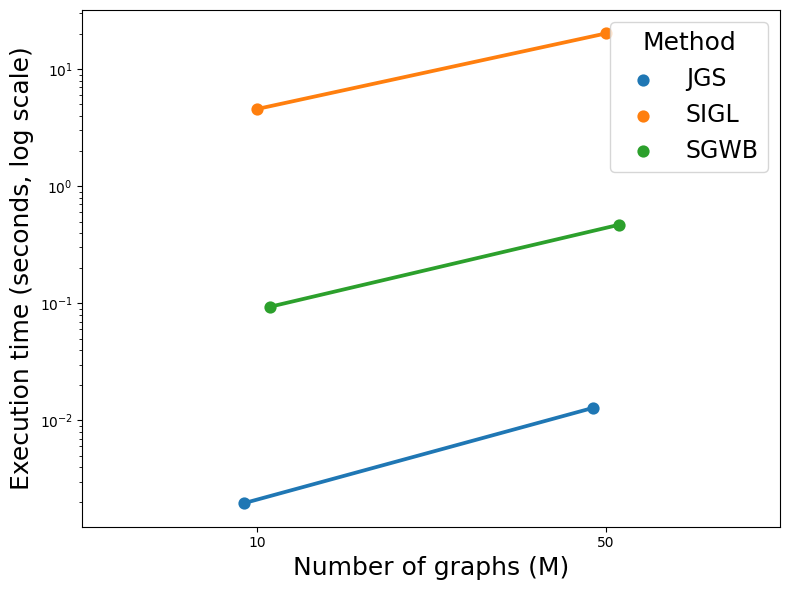

In [19]:
plot_time_pointplot(resultsM, mode="M", savepath="pointplot_timesM.png")

# II-Other time comparison

In [55]:
def run_methods_raw_results(
    graphon_id=1,
    M=50,
    vec_n= np.array([10, 20,30, 50, 80]*10),
    REP=10,
    graphon_size=1000,
    methods=["JGS","SIGL","SGWB","SBA","SAS","USVT"],
):
    """
    Run all methods and store raw results for each repetition.

    Returns
    -------
    DataFrame with columns:
        repetition, method, MISE, Time
    """

    #vec_n = np.repeat(n, M)
    true_graphon = generate_true_graphon_matrix(graphon_size, graphon_id)

    rows = []

    inr_dim_hidden = [20, 20]
    gnn_dim_hidden = [8, 8, 8]
    n_epochs, epoch_show, w0, lr, batch_size, Res = 100, 20, 10, 0.01, 1024, 1000


    for rep in range(REP):

        print(f"Repetition {rep+1}/{REP}")

        graphs_data = generate_graphs_from_graphon(vec_n, graphon_id)
        graphs = graphs_data["graphs"]

        for method in methods:

            try:

                start = time.time()

                if method == "JGS":

                    est = joint_graph_sorting_estimate(graphs)
                    W_est = resize_graphon_to_common(
                        est["edge_frequencies"], graphon_size
                    )

                elif method in ["SBA","SAS","USVT","SGWB"]:

                    _, W_est = learner.estimate_graphon(
                        graphs, method=method, args=args
                    )

                elif method == "SIGL":

                    model_SIGL,_ = coords_prediction(
                        inr_dim_hidden, gnn_dim_hidden,
                        n_epochs, epoch_show, w0, graphs, lr
                    )

                    X_all,y_all,w_all = graph2XY(graphs, model_SIGL)

                    trained_inr = train_graphon(
                        inr_dim_hidden, w0, X_all, y_all, w_all,
                        n_epochs, epoch_show, lr, batch_size
                    )

                    W_est = get_graphon(graphon_size, trained_inr)

                elapsed = time.time() - start

                W_est = resize_graphon_to_common(W_est, graphon_size)
                mise = graphon_L2_norm(W_est, true_graphon)

            except Exception as e:

                print(f"Error with {method}: {e}")
                elapsed = np.nan
                mise = np.nan

            rows.append({
                "repetition":rep,
                "method":method,
                "MISE":mise,
                "Time":elapsed,
                "M":M,
                "n":n,
                "graphon":graphon_id
            })

    df = pd.DataFrame(rows)

    return df

In [60]:
df=run_methods_raw_results(
    graphon_id=0,
    M=50,
    vec_n = np.array([10, 20,30, 50, 80]*10),
    REP=50,
    graphon_size=1000,
    methods=["JGS","SIGL","SGWB","SBA","SAS","USVT"],
)

Repetition 1/50
epoch:  1  loss:  9.164861731231213
epoch:  20  loss:  6.877304919064045
epoch:  40  loss:  7.93734672665596
epoch:  60  loss:  6.861374236643314
epoch:  80  loss:  6.720148473978043
epoch:  100  loss:  6.710225731134415
Epoch: 1, Loss: 0.01220
Epoch: 20, Loss: 0.00428
Epoch: 40, Loss: 0.00424
Epoch: 60, Loss: 0.00420
Epoch: 80, Loss: 0.00422
Epoch: 100, Loss: 0.00420
2
Repetition 2/50
epoch:  1  loss:  9.4523049518466
epoch:  20  loss:  7.737884595990181
epoch:  40  loss:  7.547674283385277
epoch:  60  loss:  7.493017420172691
epoch:  80  loss:  7.467307232320309
epoch:  100  loss:  7.464426763355732
Epoch: 1, Loss: 0.02986
Epoch: 20, Loss: 0.00453
Epoch: 40, Loss: 0.00453
Epoch: 60, Loss: 0.00452
Epoch: 80, Loss: 0.00449
Epoch: 100, Loss: 0.00446
3
Repetition 3/50
epoch:  1  loss:  8.648672938346863
epoch:  20  loss:  7.154419027268887
epoch:  40  loss:  7.070723757147789
epoch:  60  loss:  7.10817114263773
epoch:  80  loss:  7.5227158442139626
epoch:  100  loss:  7.1

In [66]:
df.to_csv("results_methods_time_accuracy.csv", index=False)

In [73]:
method_palette = {
    "JGS": "#1b9e77",
    "SIGL": "#d95f02",
    "SGWB": "#7570b3",
    "USVT": "#e7298a",
    "SBA": "#66a61e",
    "SAS": "#e6ab02"
}

In [74]:
def plot_mise_boxplot(df, savepath="boxplot_mise.pdf"):

    sns.set_theme(style="whitegrid", font_scale=1.2)

    plt.figure(figsize=(8,5))

    order = (
        df.groupby("method")["MISE"]
        .median()
        .sort_values()
        .index
    )

    sns.boxplot(
        data=df,
        x="method",
        y="MISE",
        order=order,
        palette=method_palette,
        width=0.6,
        showfliers=False
    )

    plt.yscale("log")

    plt.xlabel("Method", fontsize=14)
    plt.ylabel("MISE (log scale)", fontsize=14)

    sns.despine()

    plt.tight_layout()

    plt.savefig(savepath, format="pdf")
    print(f"Saved: {savepath}")

    plt.show()

Saved: add_mise_methods.pdf


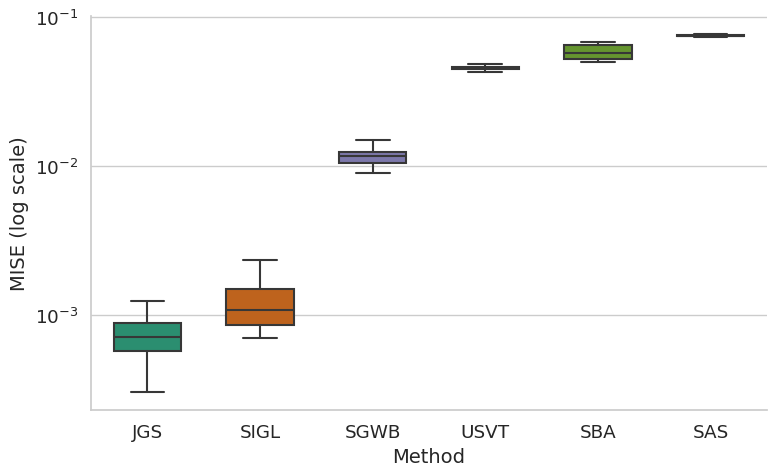

In [75]:
plot_mise_boxplot(df, "add_mise_methods.pdf")

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_time_boxplot(df, savepath="boxplot_time.pdf"):

    sns.set_theme(style="whitegrid", font_scale=1.2)

    plt.figure(figsize=(8,5))

    order = (
        df.groupby("method")["Time"]
        .median()
        .sort_values()
        .index
    )

    sns.boxplot(
        data=df,
        x="method",
        y="Time",
        order=order,
        palette=method_palette,
        width=0.6,
        showfliers=False
    )



    plt.yscale("log")

    plt.xlabel("Method", fontsize=14)
    plt.ylabel("Execution time (seconds, log scale)", fontsize=14)

    sns.despine()

    plt.tight_layout()

    plt.savefig(savepath, format="pdf")
    print(f"Saved: {savepath}")

    plt.show()

Saved: add_time_methods.pdf


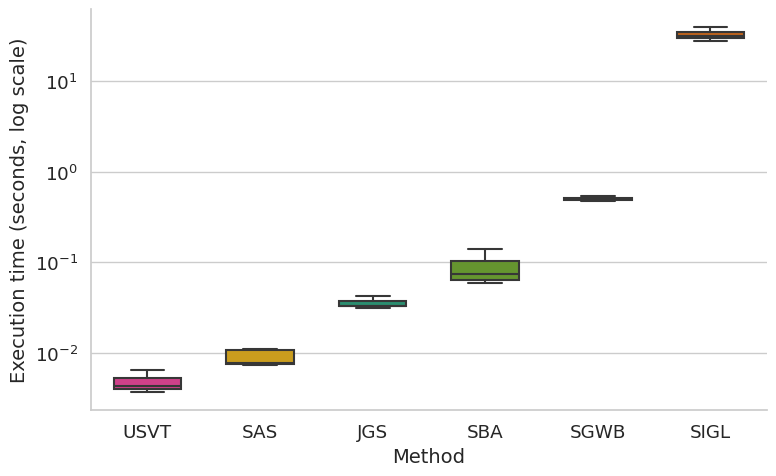

In [78]:
plot_time_boxplot(df, "add_time_methods.pdf")